# package_DBR

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
from package_LAB import *

# LL_RT()

In [3]:
help(LL_RT)

Help on function LL_RT in module package_LAB:

LL_RT(MV, Kp, Tlead, Tlag, Ts, PV, PVInit=0, method='EBD')
    The function "FO_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "FO_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

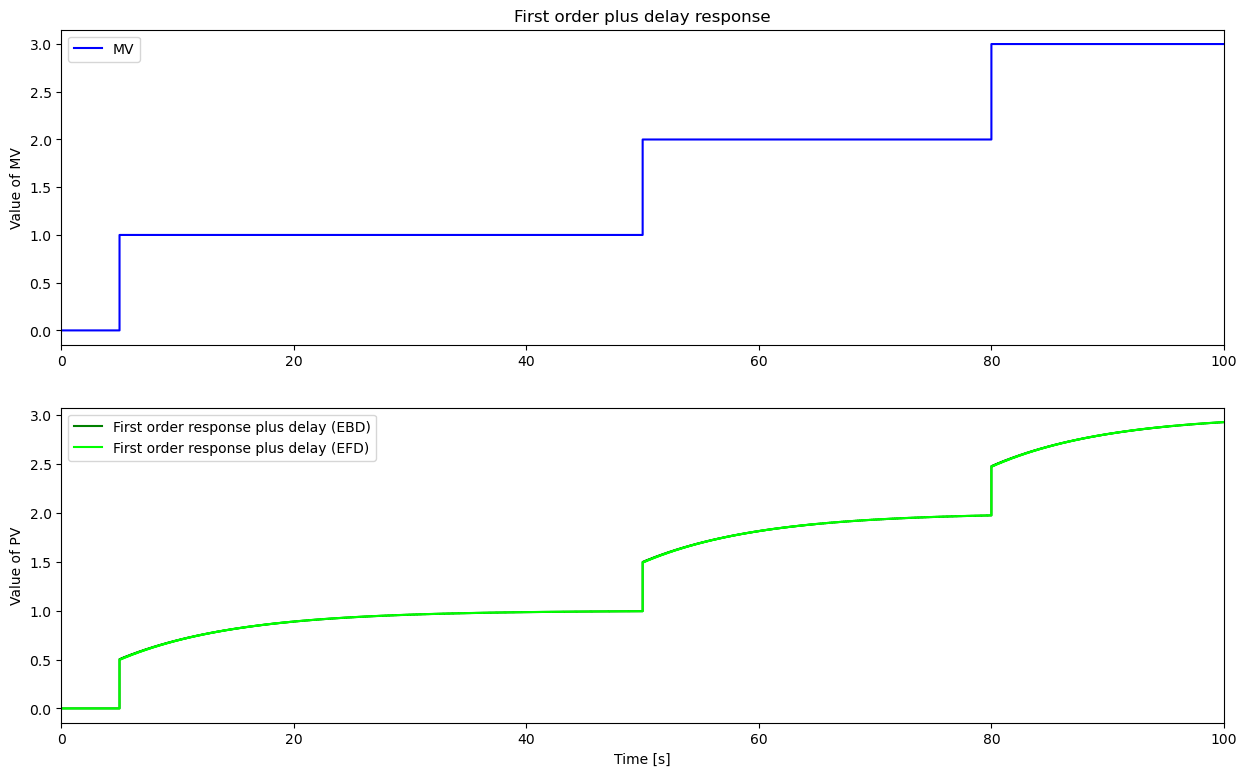

In [4]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
MVDelay = []
PV_EBD = []
PV_EFD = []

# Parameters
Kp = 1
Tlead = 5
Tlag = 10
theta = 10

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    Delay_RT(MV,theta,Ts,MVDelay)
    LL_RT(MV,Kp,Tlead,Tlag,Ts,PV_EBD,0)
    LL_RT(MV,Kp,Tlead,Tlag,Ts,PV_EFD,0,'EFD')


plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV')
plt.title('First order plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'g-',label='First order response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'lime',label='First order response plus delay (EFD)',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

# PID_RT()

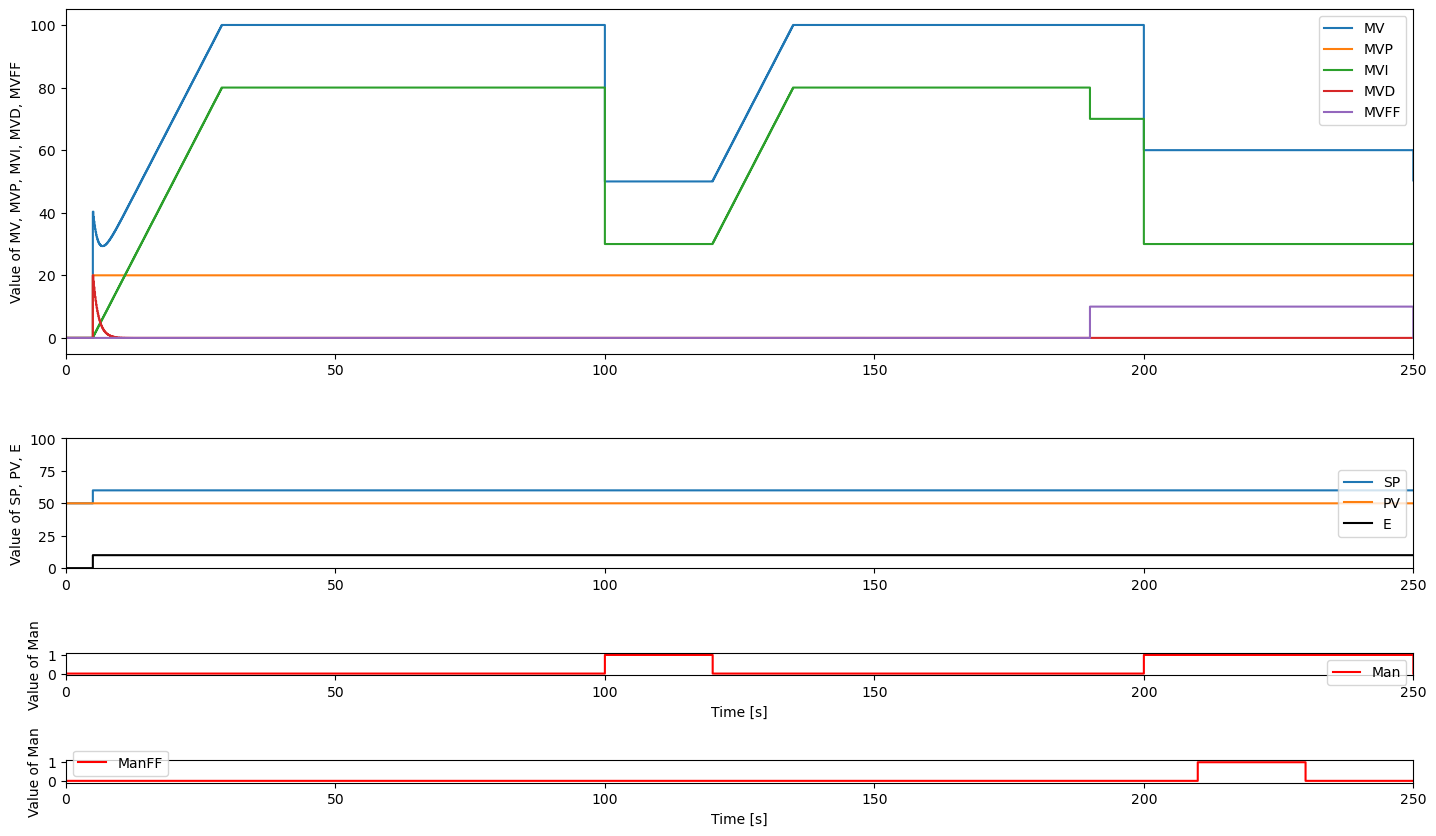

In [5]:
TSim = 250
Ts = 0.1
N = int(TSim/Ts) + 1

PVPath  = {0:50, TSim:50}

SPPath = {0: 50, 5 :60, TSim:60 }

MVFFPath = {0:0, 190:10,  TSim : 0}

ManPath = {0:False, 100: True , 120: False, 200:True, TSim :False}

MVManPath = {0:50, TSim:50}

ManFFPath = {0:False, 210: True , 230:False, TSim:False}


#PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVmax, MV, MVP, MVI, MVD, E)

t = []
MV = []

MVP = []
MVI = []
MVD = []

SP=[]
MVMan=[]
PV = []
E = []
MVFF = []
Man =[]
ManFF = []

# Parameters
Kc = 2
Ti = 6
Td = 1
alpha = 0.9
MVMin = 0
MVMax = 100


for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(PVPath,t,PV)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(MVFFPath,t,MVFF)
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t, MVMan)
    SelectPath_RT(ManFFPath,t, ManFF)
    


    # SelectPath_RT(MVManPath,t,MVMan)

    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF)

plt.figure(figsize = (15,9))


plt.subplot(8,1,(1,4))
plt.step(t,MV, label='MV',where='post')
plt.step(t,MVP, label='MVP',where='post')
plt.step(t,MVI,label='MVI',where='post')
plt.step(t,MVD,label='MVD',where='post')
plt.step(t,MVFF,label='MVFF',where='post')
# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV, MVP, MVI, MVD, MVFF')
plt.legend(loc='best')
plt.xlim([0, TSim])



plt.subplot(8,1,(5,6))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')

plt.step(t,E,'black',label='E',where='post')

plt.ylim((0,100))
# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV, E')
plt.legend(loc='right')
plt.xlim([0, TSim])



plt.subplot(8,1,7)
plt.ylim((-0.1,1.1))
plt.step(t,Man,'r-',label='Man',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of Man')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    


plt.subplot(8,1,8)
plt.ylim((-0.1,1.1))
plt.step(t,ManFF,'r-',label='ManFF',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of Man')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

plt.tight_layout(pad=3.0) # 'pad' defines the space around the figure edges
plt.show()
